In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("HeartRisk_Synthetic_dataset.csv")

In [3]:
df.head()

,age,gender,family_history,systolic_bp,diastolic_bp,cholesterol_total,glucose,bmi,diabetes,smoking,...,anxiety,upper_abdominal_discomfort,sudden_weakness,clammy_skin,symptom_count,chest_pain_severity,bp_stage,risk_score,heart_attack_risk_level,heart_attack_risk_percentage
0,69,Male,0,136,87,221,87,42.7,0,0,...,1,0,0,1,9,6,stage1,73.5,2,73.5
1,32,Female,1,120,88,201,87,35.4,0,0,...,0,0,1,0,6,4,stage1,41.2,1,41.2
2,89,Female,1,140,98,281,99,33.4,0,0,...,0,1,0,0,9,6,stage2,86.3,2,86.3
3,78,Female,1,132,80,223,178,25.3,1,0,...,1,0,0,1,9,3,stage1,66.7,1,66.7
4,38,Female,0,111,66,208,70,28.2,0,0,...,0,0,0,1,2,1,normal,7.8,0,7.8


In [4]:
df.shape

(60000, 34)

In [5]:
df.columns

Index(['age', 'gender', 'family_history', 'systolic_bp', 'diastolic_bp',
       'cholesterol_total', 'glucose', 'bmi', 'diabetes', 'smoking',
       'chest_pain', 'chest_pressure', 'shortness_of_breath', 'left_arm_pain',
       'right_arm_pain', 'jaw_pain', 'neck_pain', 'back_pain', 'cold_sweating',
       'nausea', 'vomiting', 'dizziness', 'extreme_fatigue',
       'irregular_heartbeat', 'anxiety', 'upper_abdominal_discomfort',
       'sudden_weakness', 'clammy_skin', 'symptom_count',
       'chest_pain_severity', 'bp_stage', 'risk_score',
       'heart_attack_risk_level', 'heart_attack_risk_percentage'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           60000 non-null  int64  
 1   gender                        60000 non-null  object 
 2   family_history                60000 non-null  int64  
 3   systolic_bp                   60000 non-null  int64  
 4   diastolic_bp                  60000 non-null  int64  
 5   cholesterol_total             60000 non-null  int64  
 6   glucose                       60000 non-null  int64  
 7   bmi                           60000 non-null  float64
 8   diabetes                      60000 non-null  int64  
 9   smoking                       60000 non-null  int64  
 10  chest_pain                    60000 non-null  int64  
 11  chest_pressure                60000 non-null  int64  
 12  shortness_of_breath           60000 non-null  int64  
 13  l

In [7]:
# TARGET COLUMN = "heart_attack_risk_level"

In [8]:
# Target column values check
df['heart_attack_risk_level'].value_counts()

,count
heart_attack_risk_level,
1,26551
2,25920
0,7529


In [9]:
# Percentage distribution
df['heart_attack_risk_level'].value_counts(normalize=True) * 100

,proportion
heart_attack_risk_level,
1,44.251667
2,43.200000
0,12.548333


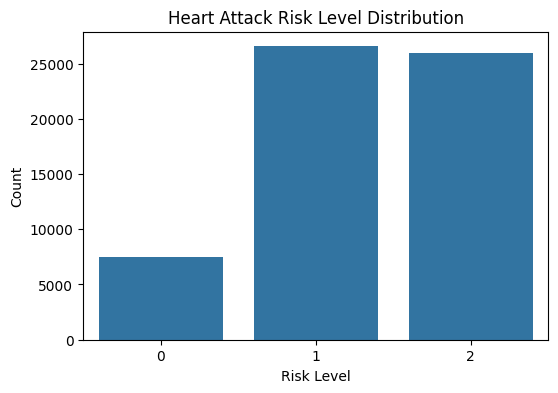

In [10]:
# Visualize target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='heart_attack_risk_level', data=df)
plt.title("Heart Attack Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

| Class | Meaning (assumed) | %          |
| ----- | ----------------- | ---------- |
| 0     | Low risk          | **12.5%**  |
| 1     | Medium risk       | **44.25%** |
| 2     | High risk         | **43.2%**  |

# Feature selection + Data leakage removal

In [11]:
# Unusual columns
# risk_score
# heart_attack_risk_percentage

In [12]:
X = df.drop(['heart_attack_risk_level','risk_score','heart_attack_risk_percentage'], axis=1)
y = df['heart_attack_risk_level']

In [13]:
X.shape

(60000, 31)

In [14]:
# Categorical columns identify
X.select_dtypes(include='object').columns

Index(['gender', 'bp_stage'], dtype='object')

# Preprocessing (Encoding + Scaling)

In [15]:
# Required preprocessing imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [16]:
# Numerical columns list
num_cols = X.select_dtypes(exclude='object').columns
num_cols

Index(['age', 'family_history', 'systolic_bp', 'diastolic_bp',
       'cholesterol_total', 'glucose', 'bmi', 'diabetes', 'smoking',
       'chest_pain', 'chest_pressure', 'shortness_of_breath', 'left_arm_pain',
       'right_arm_pain', 'jaw_pain', 'neck_pain', 'back_pain', 'cold_sweating',
       'nausea', 'vomiting', 'dizziness', 'extreme_fatigue',
       'irregular_heartbeat', 'anxiety', 'upper_abdominal_discomfort',
       'sudden_weakness', 'clammy_skin', 'symptom_count',
       'chest_pain_severity'],
      dtype='object')

In [17]:
# Preprocessing for numerical data
num_transformer = StandardScaler()

In [18]:
# Preprocessing for categorical data
cat_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

In [19]:
# Combine both
preprocessor = ColumnTransformer(transformers=[('num', num_transformer, num_cols),('cat', cat_transformer, ['gender', 'bp_stage'])])

# Train–Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
X_train.shape, X_test.shape

((48000, 31), (12000, 31))

# Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
model = Pipeline(steps=[('preprocessing', preprocessor),('classifier', LogisticRegression(max_iter=1000,multi_class='auto',n_jobs=-1))])

In [24]:
# Model train

In [25]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'family_history', 'systolic_bp', 'diastolic_bp',
       'cholesterol_total', 'glucose', 'bmi', 'diabetes', 'smoking',
       'chest_pain', 'chest_pressure', 'shortness_of_breath', 'left_arm_pain',
       'right_arm_pain', 'jaw_pain', 'neck_pain', 'back_pain', 'cold_sweating',
       'nausea',...iting', 'dizziness', 'extreme_fatigue',
       'irregular_heartbeat', 'anxiety', 'upper_abdominal_discomfort',
       'sudden_weakness', 'clammy_skin', 'symptom_count',
       'chest_pain_severity'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'bp_stage'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, multi_class='auto',
                                    n_jobs=-1))])

In [26]:
y_pred = model.predict(X_test)

In [27]:
# Train data prediction
y_train_pred = model.predict(X_train)

In [28]:
# Train accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
train_accuracy

0.9264583333333334

In [29]:
# Test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
test_accuracy

0.92675

| Metric             | Value      |
| ------------------ | ---------- |
| **Train Accuracy** | **92.64%** |
| **Test Accuracy**  | **92.68%** |

In [30]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1506
           1       0.92      0.91      0.92      5310
           2       0.92      0.93      0.92      5184

    accuracy                           0.93     12000
   macro avg       0.94      0.94      0.94     12000
weighted avg       0.93      0.93      0.93     12000



In [31]:
# Confusion matrix
confusion_matrix(y_test, y_pred)

array([[1491,   15,    0],
       [  42, 4831,  437],
       [   0,  385, 4799]])